<a href="https://colab.research.google.com/github/ammar01-me/deeplense_gsoc/blob/main/deeplense_gravitational_lense_finding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Preprosessing the image data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/gravitational_lense/lens-finding-test.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [5]:
import os
print(os.listdir("/content/dataset"))

['__MACOSX', 'train_lenses', 'test_lenses', 'train_nonlenses', 'test_nonlenses']


##### plotting the data for lense vs non lense and classs imbalance

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [12]:
path = "dataset/train_lenses"
files = os.listdir(path)
files = files[:20]

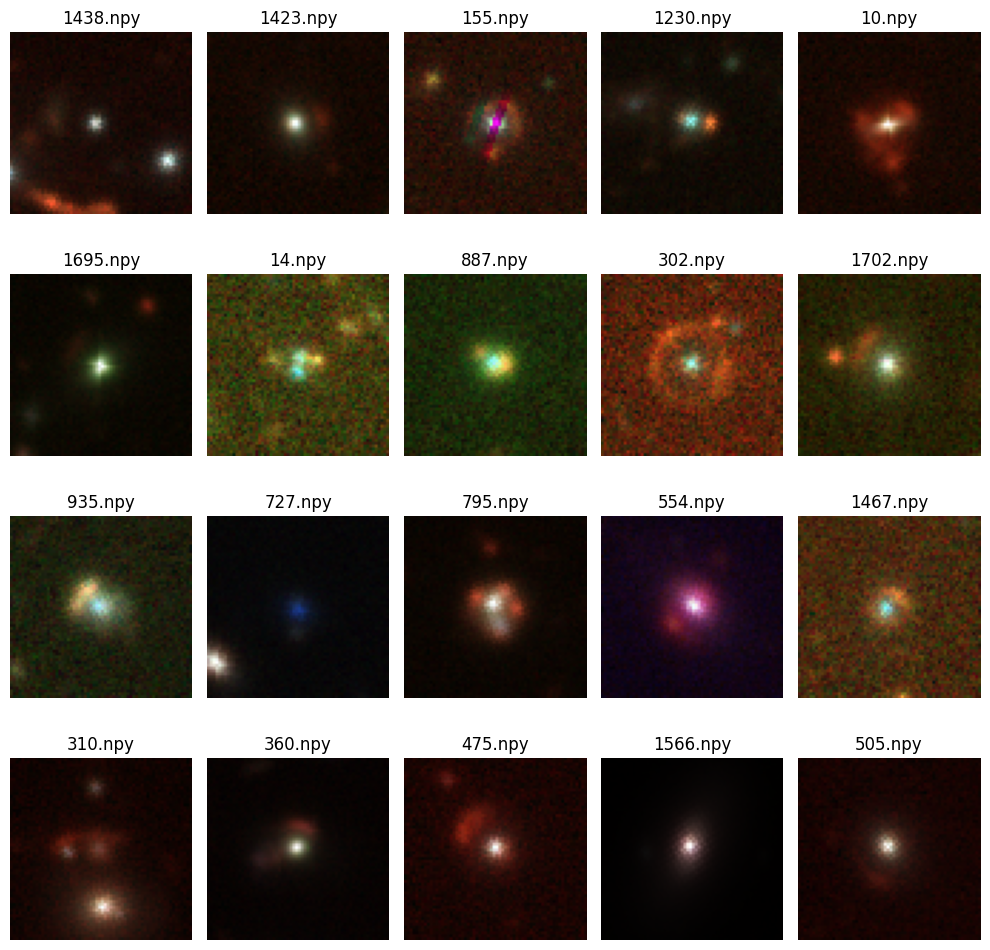

In [13]:
plt.figure(figsize=(10,10))

for i, file in enumerate(files):

    img = np.load(os.path.join(path, file))   # shape (3,64,64)

    img = np.transpose(img, (1,2,0))  # convert to (64,64,3)

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

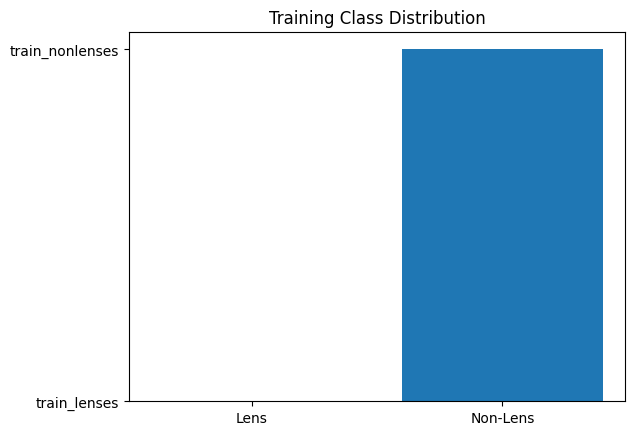

In [14]:
labels = ["Lens", "Non-Lens"]
values = ['train_lenses', 'train_nonlenses']

plt.bar(labels, values)
plt.title("Training Class Distribution")
plt.show()

In [15]:
#checking the class imbalance
dataset_path = "dataset"
train_lenses = len(os.listdir(os.path.join(dataset_path, "train_lenses")))
train_nonlenses = len(os.listdir(os.path.join(dataset_path, "train_nonlenses")))

test_lenses = len(os.listdir(os.path.join(dataset_path, "test_lenses")))
test_nonlenses = len(os.listdir(os.path.join(dataset_path, "test_nonlenses")))

print("Training Dataset")
print("Lenses:", train_lenses)
print("Non-Lenses:", train_nonlenses)

print("\nTest Dataset")
print("Lenses:", test_lenses)
print("Non-Lenses:", test_nonlenses)

Training Dataset
Lenses: 1730
Non-Lenses: 28675

Test Dataset
Lenses: 195
Non-Lenses: 19455


In [16]:
ratio = train_nonlenses / train_lenses

print("Class imbalance ratio (non-lens : lens) =", ratio)

Class imbalance ratio (non-lens : lens) = 16.57514450867052


In [17]:
#lense vs  non lense
#plotting the lense vs non lense img
lens_path = "dataset/train_lenses"
nonlens_path = "dataset/train_nonlenses"

In [18]:
lens_files = os.listdir(lens_path)[:10]
nonlens_files = os.listdir(nonlens_path)[:10]

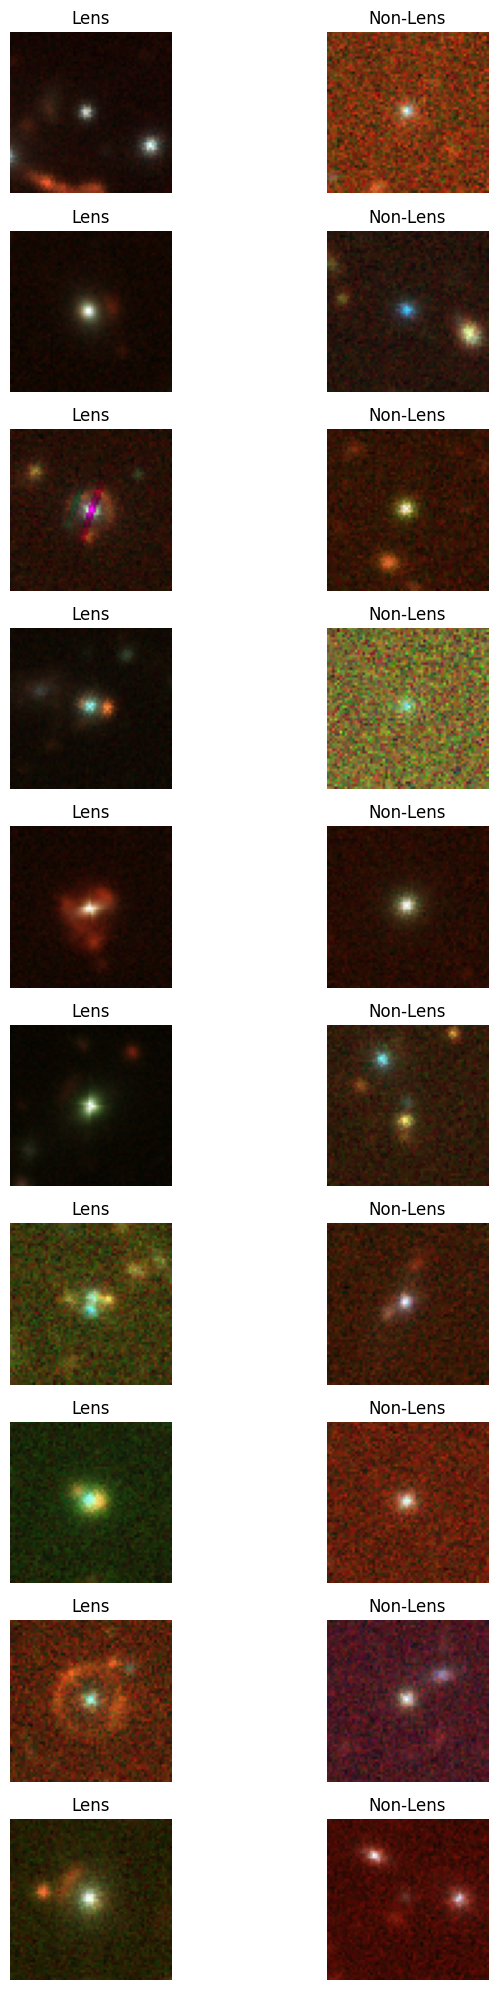

In [19]:
plt.figure(figsize=(8,20))

for i in range(10):

    # Load images
    lens_img = np.load(os.path.join(lens_path, lens_files[i]))
    nonlens_img = np.load(os.path.join(nonlens_path, nonlens_files[i]))

    # Convert (3,64,64) → (64,64,3)
    lens_img = np.transpose(lens_img, (1,2,0))
    nonlens_img = np.transpose(nonlens_img, (1,2,0))

    # Normalize for visualization
    lens_img = (lens_img - lens_img.min())/(lens_img.max()-lens_img.min())
    nonlens_img = (nonlens_img - nonlens_img.min())/(nonlens_img.max()-nonlens_img.min())

    # Lens image
    plt.subplot(10,2,2*i+1)
    plt.imshow(lens_img)
    plt.title("Lens")
    plt.axis("off")

    # Non-lens image
    plt.subplot(10,2,2*i+2)
    plt.imshow(nonlens_img)
    plt.title("Non-Lens")
    plt.axis("off")

plt.tight_layout()
plt.show()

### creating the model pipeline

In [21]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
train_lens = "dataset/train_lenses"
train_nonlens = "dataset/train_nonlenses"

test_lens = "dataset/test_lenses"
test_nonlens = "dataset/test_nonlenses"

In [37]:
# creating a custom dataset class
class LensDataset(Dataset):

    def __init__(self, lens_dir, nonlens_dir):

        self.images = []
        self.labels = []

        for f in os.listdir(lens_dir):
            self.images.append(os.path.join(lens_dir, f))
            self.labels.append(1)

        for f in os.listdir(nonlens_dir):
            self.images.append(os.path.join(nonlens_dir, f))
            self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = np.load(self.images[idx])     # shape (3,64,64)
        img = (img - img.min()) / (img.max() - img.min())
        img = torch.tensor(img, dtype=torch.float32)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return img, label

In [38]:
#data loader
train_dataset = LensDataset("dataset/train_lenses","dataset/train_nonlenses")
test_dataset = LensDataset("dataset/test_lenses","dataset/test_nonlenses")

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

### using resnet cnn model

In [39]:
resnet18_model = models.resnet18(pretrained=True)

In [40]:
resnet18_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:
resnet18_model.conv1 = nn.Conv2d(3,64,kernel_size=7,stride=2,padding=3,bias=False)

In [42]:
resnet18_model.fc = nn.Linear(resnet18_model.fc.in_features,1)

In [43]:
#freezing the feature extraction layer
for param in resnet18_model.parameters():
    param.requires_grad = False

In [44]:
#for classification layer
for param in resnet18_model.fc.parameters():
    param.requires_grad = True

In [45]:
resnet18_model = resnet18_model.to(device)

In [46]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18_model.fc.parameters(), lr=0.001)

In [47]:
epochs = 10

for epoch in range(epochs):

    resnet18_model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet18_model(images).squeeze()

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)

    print("Epoch:", epoch, "Loss:", avg_loss)

Epoch: 0 Loss: 0.17532384815526936
Epoch: 1 Loss: 0.15636115570353848
Epoch: 2 Loss: 0.1535235538953361
Epoch: 3 Loss: 0.15306454134632988
Epoch: 4 Loss: 0.15191628519332057
Epoch: 5 Loss: 0.1497792158115236
Epoch: 6 Loss: 0.151473244826469
Epoch: 7 Loss: 0.15280690244335357
Epoch: 8 Loss: 0.15103732103327158
Epoch: 9 Loss: 0.15183640686652136


### model evaluation

In [48]:
resnet18_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [49]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet18_model(images)

        preds = torch.sigmoid(outputs) > 0.5

        correct += (preds.squeeze().cpu() == labels).sum().item()
        total += labels.size(0)

print("Accuracy:", correct/total)

Accuracy: 0.9768447837150127


In [50]:
#Receiver Operating Characteristic(ROC) and Area Under the Curve(AUC)
from sklearn.metrics import roc_curve, auc
y_true = []
y_scores = []

resnet18_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet18_model(images)

        probs = torch.sigmoid(outputs)

        y_true.extend(labels.numpy())
        y_scores.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.8815053805955888


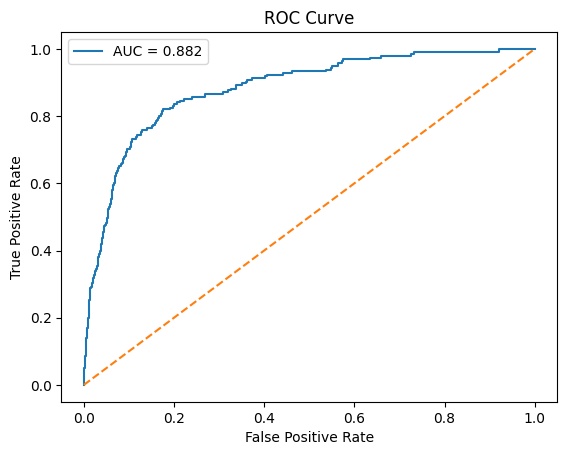

In [51]:
import matplotlib.pyplot as plt

plt.plot(fpr,tpr,label="AUC = %.3f"%roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()